In [1]:
import pandas as pd

#### 21.07

Missing reward. Also: currently multi-chunk implementation bugged. Will have to re-run this week.
hotfix: concentrate only on the 1024_1024 rollouts and see what we can find. Grade anew.

Dataset: '/u/rfechner/verl/mathlighteval_chunk0_graded.parquet'
Questions:

1) "Solve for $a$: $$\sqrt{4+\sqrt{16+16a}}+ \sqrt{1+\sqrt{1+a}} = 6.$$ Let's think step by step and output the final answer within \\boxed{}."
Answer: Use a small trick of pushing a scalar into the sqrt.
Why didn't the model get the answer correct?
    - Instead of answering the question, code solution is given. Pretty sure pre-training data has a very similar question and it was solved using python.
    -> hallucination

2) The sum of a 15-term arithmetic series with first term 7  is $-210$.  What is the common difference?
Mislabeled. Correct answer is -3, not 3.

3) In the sequence 0, 1, 1, 3, 6, 9, 27, ..., the first term is 0.   Subsequent terms are produced by alternately adding and  multiplying by each successive integer beginning with 1.  For  instance, the second term is produced by adding  1 to the first term; the third term is produced by  multiplying the second term by 1; the fourth term  is produced by adding 2 to the third term; and so  on.  What is the value of the first term that is greater than 125? Let's think step by step and output the final answer within \\boxed{}.

Instructions are just very unclear imo. Model fails this, because it's (as in question 1) writing a recipe to solve in python instead of actually solving. 

4) "Two positive numbers $p$ and $q$ have the property that their sum is equal to their product. If their difference is $7$, what is $\frac{1}{\frac{1}{p^2}+\frac{1}{q^2}}$? Your answer will be of the form $\frac{a+b\sqrt{c}}{d}$, where $a$ and $b$ don't both share the same common factor with $d$ and $c$ has no square as a factor. Find $a+b+c+d$. Let's think step by step and output the final answer within \\boxed{}."

7) "Find all solutions to the equation $\sqrt{3x+6}=x+2$.  If there are multiple solutions, order them from least to greatest, separated by comma(s). Let's think step by step and output the final answer within \\boxed{}."
Mislabeled. Correct answer should be -2, 1 but solution is only 1.

In [2]:
df = pd.read_parquet('/u/rfechner/verl/mathlighteval_chunk0_graded.parquet')

In [3]:
import numpy as np
df['reward_mean'] = df['rewards'].apply(np.mean)

In [4]:
df_ = df.sort_values(by='reward_mean')

In [5]:
df_.head(20)

,level,type,data_source,prompt,ability,reward_model,extra_info,responses,rewards,reward_mean
319,Level 5,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Solve for $a$: $$\sqrt{4+\sqrt{1...,math,"{'ground_truth': '8', 'style': 'rule'}","{'index': 319, 'split': 'test'}",[ To solve the equation \(\sqrt{4+\sqrt{16+16a...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000
333,Level 5,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'The sum of a 15-term arithmetic ...,math,"{'ground_truth': '3', 'style': 'rule'}","{'index': 333, 'split': 'test'}",[ To find the common difference of the arithme...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000
85,Level 4,Algebra,DigitalLearningGmbH/MATH-lighteval,"[{'content': 'In the sequence 0, 1, 1, 3, 6, 9...",math,"{'ground_truth': '129', 'style': 'rule'}","{'index': 85, 'split': 'test'}","[ To solve this problem, we need to generate t...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000977
427,Level 5,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'The equation of a circle which h...,math,"{'ground_truth': '21', 'style': 'rule'}","{'index': 427, 'split': 'test'}",[ To find the equation of the circle with cent...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.001953
91,Level 5,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Two positive numbers $p$ and $q$...,math,"{'ground_truth': '161', 'style': 'rule'}","{'index': 91, 'split': 'test'}",[ Let's solve the problem step by step.\n\n1. ...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.002930
295,Level 4,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'A man nearing retirement wants t...,math,"{'ground_truth': '74726', 'style': 'rule'}","{'index': 295, 'split': 'test'}",[ To determine how much money the man must inv...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.002930
635,Level 5,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Suppose that $f$ is a quadratic ...,math,"{'ground_truth': '5', 'style': 'rule'}","{'index': 635, 'split': 'test'}",[ To determine the maximum degree of the polyn...,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.005859
414,Level 3,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Find all solutions to the equati...,math,"{'ground_truth': '1', 'style': 'rule'}","{'index': 414, 'split': 'test'}","[ To solve the equation \(\sqrt{3x+6} = x+2\),...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.006836
20,Level 5,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Suppose the roots of the polynom...,math,"{'ground_truth': '18', 'style': 'rule'}","{'index': 20, 'split': 'test'}","[ To solve this problem, we need to use the pr...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.010742
620,Level 5,Algebra,DigitalLearningGmbH/MATH-lighteval,"[{'content': 'If $x$, $y$, and $z$ are positiv...",math,"{'ground_truth': '10', 'style': 'rule'}","{'index': 620, 'split': 'test'}",[ To solve the equation \(6xyz + 30xy + 21xz +...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.011719


In [20]:
idx = 14
prompt, results, rewards = df_.iloc[idx]['prompt'][0]['content'], df_.iloc[idx]['responses'], df_.iloc[idx]['rewards']

In [ ]:
prompt 

"When the first $50$ counting numbers are arranged in columns, as shown, what is the sum of all of the counting numbers in column $\\text E?$ \\begin{tabular}{lllll}\nA & B & C & D & E\\\\\n1 & 2 & 3 & 4 & 5\\\\\n10 & 9 & 8 & 7 & 6\\\\\n11 & 12 & 13 & 14 & 15\\\\\n20 & 19 & 18 & 17 & 16\\\\\n. & . & . & . & .\\\\\n. & . & . & . & .\\\\\n. & . & . & . & .\n\\end{tabular} Let's think step by step and output the final answer within \\boxed{}."

In [26]:
results[4]

" To determine the sum of all the counting numbers in column E, we need to first understand the arrangement of the numbers. The numbers are arranged in a grid where each column contains 5 numbers, and the numbers are filled row by row. The first 50 numbers are arranged as follows:\n\n1 2 3 4 5\n10 9 8 7 6\n11 12 13 14 15\n20 19 18 17 16\n...\n\nWe can see that the numbers in column E are the 5th numbers in each row. So, the numbers in column E are: 5, 6, 15, 16, 25, 26, 35, 36, 45, 46, 55, 56, 65, 66, 75, 76, 85, 86, 95, 96.\n\nTo find the sum of these numbers, we can use the formula for the sum of an arithmetic series. The first term \\(a\\) is 5, the common difference \\(d\\) is 10, and the number of terms \\(n\\) is 20. The sum \\(S_n\\) of the first \\(n\\) terms of an arithmetic series is given by:\n\n\\[ S_n = \\frac{n}{2} \\left(2a + (n-1)d\\right) \\]\n\nSubstituting the values \\(a = 5\\), \\(d = 10\\), and \\(n = 20\\):\n\n\\[ S_{20} = \\frac{20}{2} \\left(2 \\cdot 5 + (20-1)

In [ ]:
"""
    5 + 6 + 15 + 16 + 25 + 26 + 35 + 36 + 45 + 46 = 10 + 1 + 30 + 1 + 50 + 1 + 70 + 1 + 90 + 1 = 250 + 5 = 255 
"""


'\n    p + q = pq and p = q + 7. Find 1 / (1 / p^2) + (1 / q^2)\n'

In [10]:
xs = df['level'].apply(lambda x: int(x.lower().replace('level', '').strip()))
xs

608    4
609    4
610    3
611    2
612    4
      ..
395    4
396    2
397    5
398    2
399    1
Name: level, Length: 688, dtype: int64

In [ ]:
import matplotlib.pyplot as plt

In [14]:
ys = df['reward_mean']
ys_sorted = [[] for _ in range(5)]
for x, y in zip(xs, ys):
    ys_sorted[x - 1].append(y)

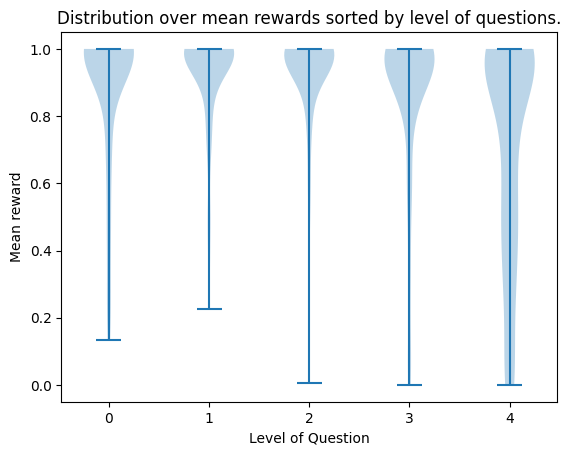

In [19]:
plt.violinplot(ys_sorted, range(5))
plt.xlabel('Level of Question')
plt.ylabel('Mean reward')
plt.title('Distribution over mean rewards sorted by level of questions.')
plt.show()

In [28]:
dfs = df.sort_values(by='reward_mean', ascending=False)

In [30]:
dfs.head(30)

,level,type,data_source,prompt,ability,reward_model,extra_info,responses,rewards,reward_mean
619,Level 2,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'How many units long is a segment...,math,"{'ground_truth': '13', 'style': 'rule'}","{'index': 619, 'split': 'test'}",[ To find the length of the segment whose endp...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
614,Level 2,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'For what value of $x$ does $2^{1...,math,"{'ground_truth': '-4', 'style': 'rule'}","{'index': 614, 'split': 'test'}",[ To solve the equation \(2^{12} = \left(\frac...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
393,Level 1,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Factor $r^2+10r+25$. Let's think...,math,"{'ground_truth': '(r+5)^2', 'style': 'rule'}","{'index': 393, 'split': 'test'}",[ To factor the quadratic expression \( r^2 + ...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
470,Level 4,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Find the constant $a$ such that ...,math,"{'ground_truth': '-5', 'style': 'rule'}","{'index': 470, 'split': 'test'}",[ To find the constant \(a\) such that \((x^2 ...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
431,Level 1,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'What is 20$\%$ of 50$\%$ of 80? ...,math,"{'ground_truth': '8', 'style': 'rule'}","{'index': 431, 'split': 'test'}","[ To find 20% of 50% of 80, we can break the p...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
612,Level 4,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'If $\frac{\sqrt{2x}}{\sqrt{3x-1}...,math,"{'ground_truth': '\frac9{19}', 'style': 'rule'}","{'index': 612, 'split': 'test'}",[ To solve the equation \(\frac{\sqrt{2x}}{\sq...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
446,Level 4,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'What is the smallest integer val...,math,"{'ground_truth': '1', 'style': 'rule'}","{'index': 446, 'split': 'test'}",[ To determine the smallest integer value of \...,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
422,Level 3,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Richard is building a rectangula...,math,"{'ground_truth': '2500', 'style': 'rule'}","{'index': 422, 'split': 'test'}","[ To solve this problem, we need to maximize t...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
16,Level 2,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Let \[f(x) = \begin{cases} 3x + ...,math,"{'ground_truth': '-25', 'style': 'rule'}","{'index': 16, 'split': 'test'}","[ To find \( f(-10) \), we need to determine w...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0
425,Level 2,Algebra,DigitalLearningGmbH/MATH-lighteval,[{'content': 'Suppose $c$ and $d$ are inversel...,math,"{'ground_truth': '12', 'style': 'rule'}","{'index': 425, 'split': 'test'}","[ To solve the problem, we need to use the pro...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0


In [41]:
loc = 612
content, responses, rewards = dfs.loc[loc].prompt[0]['content'], dfs.loc[loc].responses, dfs.loc[loc].rewards

In [42]:
content

"If $\\frac{\\sqrt{2x}}{\\sqrt{3x-1}}=\\frac32$, solve for $x$. Express your answer in simplest fractional form. Let's think step by step and output the final answer within \\boxed{}."

In [44]:
print(responses[1])

 To solve the equation \(\frac{\sqrt{2x}}{\sqrt{3x-1}} = \frac{3}{2}\), we can follow these steps:

1. Square both sides of the equation to eliminate the square roots.
2. Simplify the resulting equation.
3. Solve for \(x\).

Let's start by squaring both sides of the equation:

\[
\left(\frac{\sqrt{2x}}{\sqrt{3x-1}}\right)^2 = \left(\frac{3}{2}\right)^2
\]

This simplifies to:

\[
\frac{2x}{3x-1} = \frac{9}{4}
\]

Next, we can cross-multiply to eliminate the fractions:

\[
4 \cdot 2x = 9 \cdot (3x - 1)
\]

This simplifies to:

\[
8x = 27x - 9
\]

Rearrange the equation to isolate \(x\):

\[
8x - 27x = -9
\]

This simplifies to:

\[
-19x = -9
\]

Finally, solve for \(x\):

\[
x = \frac{9}{19}
\]

Let's verify this solution by substituting \(x = \frac{9}{19}\) back into the original equation to ensure it satisfies the equation. We'll use Python to do this.
```python
from sympy import symbols, Eq, solve, sqrt

# Define the variable
x = symbols('x')

# Define the equation
equation = Eq(sqrt

### Easy questions solverate = 1

250) "If the parabola $y_1 = x^2 + 2x + 7$ and the line $y_2 = 6x + b$ intersect at only one point, what is the value of $b$? Let's think step by step and output the final answer within \\boxed{}."

- Model found the 'trick' to solve the question every time

619) "How many units long is a segment whose endpoints are $(1,2)$ and $(-4,-10)$? Let's think step by step and output the final answer within \\boxed{}."

- just an easy question.

470) "Find the constant $a$ such that \\[(x^2 - 3x + 4)(2x^2 +ax + 7) = 2x^4 -11x^3 +30x^2 -41x +28.\\] Let's think step by step and output the final answer within \\boxed{}."
 
- straight forward question, level 4 ranking is likely given for the required work put into this task for humans

612)

"If $\frac{\sqrt{2x}}{\sqrt{3x-1}}=\frac32$, solve for $x$. Express your answer in simplest fractional form. Let's think step by step and output the final answer within \\boxed{}."

- Gets right solution but hallucinates a python output verification of the answer.
 
 
 

 